# Entrega 1 — Problema, datos, EDA y baseline
**Curso:** Aprendizaje de Máquina Aplicado (EAFIT)

**Dataset:** *Mental Illnesses Prevalence* (Our World in Data / IHME, GBD).

En este notebook documento lo que hice en la primera entrega del proyecto. Me apoyé en el flujo **CRISP-DM** que vimos en clase: primero trato de entender el problema y los datos, luego hago un análisis exploratorio, defino formalmente la tarea de aprendizaje y finalmente construyo un baseline que sea reproducible. La idea es ir dejando claras mis decisiones a medida que avanzo, porque varias de ellas las voy a retomar en las entregas siguientes.

## 1. ¿Qué problema quiero resolver?
La salud mental es una parte esencial del bienestar. Cada año, cientos de millones de personas conviven con algún trastorno mental y, como no siempre hay un diagnóstico clínico disponible, gran parte de los datos que tengo provienen de encuestas y cuestionarios estandarizados. Este dataset, publicado por *Our World in Data* a partir de estimaciones del IHME (*Global Burden of Disease*), reúne la **prevalencia estandarizada por edad** de cinco trastornos mentales en 214 entidades (países y agregados regionales) entre **1990 y 2019**.

La pregunta concreta que quiero responder en esta entrega es: **¿qué tan bien puedo estimar la prevalencia de depresión de un país en un año dado a partir de la prevalencia de los otros cuatro trastornos (esquizofrenia, ansiedad, bipolaridad y trastornos alimentarios) y del año?** Responderla me sirve, ya que me dice cuán marcada es la estructura de comorbilidad a nivel poblacional.

Es un problema de **regresión supervisada**. Elegí este dataset porque: el target es continuo y tiene un significado social claro; las variables numéricas están limpias (sin faltantes en las columnas predictoras); el tamaño es bueno; me permite empezar con baselines lineales y después comparar con familias más potentes (árboles, boosting).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 20)
DATA_PATH = Path('../data/mental-illnesses-prevalence.csv')

## 2. Carga y limpieza inicial
Lo primero que hago es cargar el CSV y ver con qué me estoy enfrentando. Los nombres de las columnas originales son larguísimos (incluyen sexo, grupo etario, etc.), así que los renombro con alias cortos para que el resto del notebook sea legible.

In [2]:
raw = pd.read_csv(DATA_PATH)
print('Shape:', raw.shape)
raw.head()

Shape: (6420, 8)


,Entity,Code,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815


In [3]:
COL_MAP = {
    'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized': 'schizophrenia',
    'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized': 'depression',
    'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized': 'anxiety',
    'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized': 'bipolar',
    'Eating disorders (share of population) - Sex: Both - Age: Age-standardized': 'eating',
}
df = raw.rename(columns=COL_MAP)
df.dtypes

Entity               str
Code                 str
Year               int64
schizophrenia    float64
depression       float64
anxiety          float64
bipolar          float64
eating           float64
dtype: object

Ahora reviso valores faltantes. Me interesa saber si los NaN están en las columnas predictoras (lo cual sería un problema serio) o en alguna columna más inofensiva.

In [4]:
# Missing values: las 270 filas sin Code corresponden a agregados regionales
print('Missing por columna:')
print(df.isna().sum())
print()
print('Entidades sin Code (agregados):')
print(df.loc[df['Code'].isna(), 'Entity'].unique())

Missing por columna:
Entity             0
Code             270
Year               0
schizophrenia      0
depression         0
anxiety            0
bipolar            0
eating             0
dtype: int64

Entidades sin Code (agregados):
<StringArray>
[            'Africa (IHME GBD)',            'America (IHME GBD)',
               'Asia (IHME GBD)',             'Europe (IHME GBD)',
           'European Union (27)',         'High-income countries',
          'Low-income countries', 'Lower-middle-income countries',
 'Upper-middle-income countries']
Length: 9, dtype: str


Como sospechaba, los 270 faltantes de `Code` corresponden a **agregados regionales** (África, Europa, grupos de ingreso, etc.) — 9 entidades × 30 años cada una. No son países, son promedios regionales. Mezclarlos con países en el modelo sería combinar unidades heterogéneas, así que los separo y me quedo únicamente con los países para todo el análisis.

In [5]:
# Separamos países vs agregados. Para el modelo usaremos solo países.
aggregates = df[df['Code'].isna()].copy()
countries = df[df['Code'].notna()].copy().reset_index(drop=True)
print(f'Países: {countries.Entity.nunique()} | filas: {len(countries)}')
print(f'Agregados: {aggregates.Entity.nunique()} | filas: {len(aggregates)}')
print(f'Años: {countries.Year.min()}–{countries.Year.max()}')

Países: 205 | filas: 6150
Agregados: 9 | filas: 270
Años: 1990–2019


Me quedo con 205 países × 30 años = 6 150 filas. Ahora miro las estadísticas descriptivas para hacerme una idea de los rangos y la escala de cada variable.

In [6]:
countries.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,6150.0,2004.500000,8.656145,1990.000000,1997.000000,2004.500000,2012.000000,2019.000000
schizophrenia,6150.0,0.266031,0.039258,0.188416,0.241982,0.272983,0.285912,0.462045
depression,6150.0,3.766168,0.939617,1.522333,3.063132,3.642872,4.369088,7.645899
anxiety,6150.0,4.098702,1.060642,1.879996,3.425237,3.939547,4.539975,8.624634
bipolar,6150.0,0.638366,0.235506,0.181667,0.521153,0.579017,0.853304,1.506730
eating,6150.0,0.194945,0.139051,0.044780,0.095748,0.144325,0.242860,1.031688


## 3. Análisis exploratorio (EDA)
Con los datos ya cargados y limpios, paso al EDA. Me guío por el material **02_mla_eda.pdf** del curso y reviso, en este orden: la estructura y calidad de los datos, las distribuciones univariadas de cada variable, las correlaciones entre ellas, la estructura temporal y algunas relaciones bivariadas que pueden ser útiles para el modelado. La intención no es ‘describir por describir’, sino que cada hallazgo me sirva para tomar decisiones concretas sobre el modelo.

### 3.1 Distribuciones univariadas
Empiezo viendo cómo se distribuye cada trastorno por separado. Esto me dice qué tan simétricas o sesgadas son las variables, y me ayuda a decidir si necesito escalar o transformar algo.

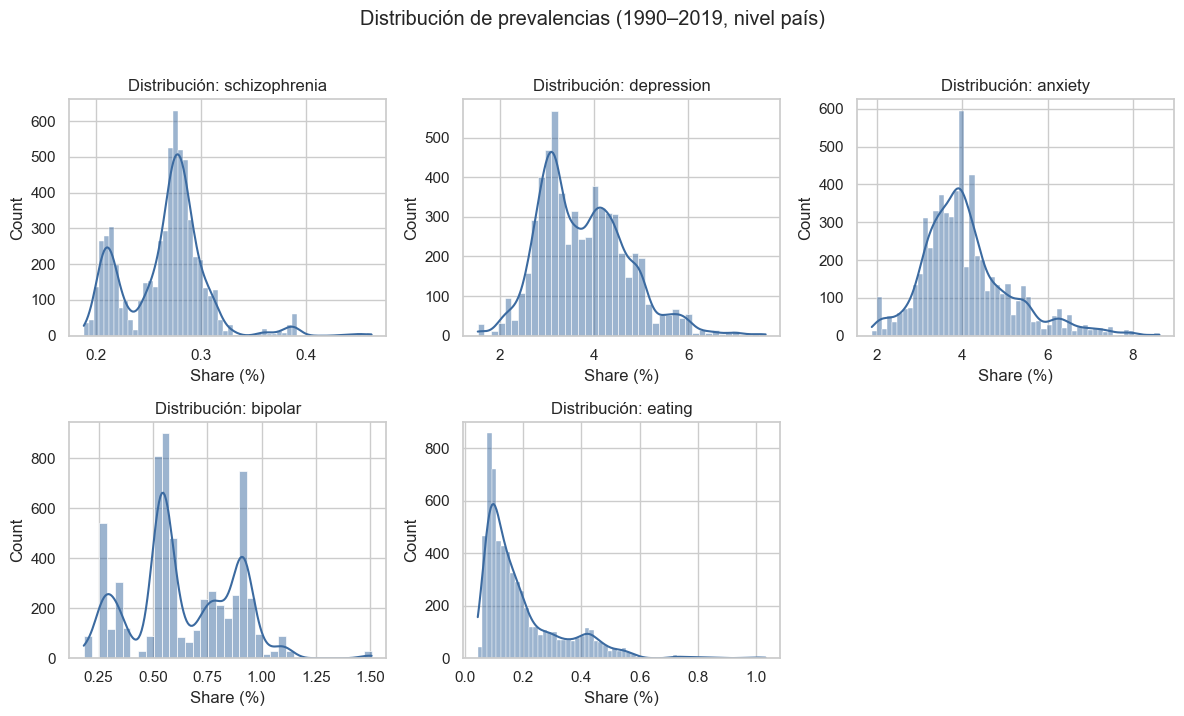

In [7]:
cols = ['schizophrenia', 'depression', 'anxiety', 'bipolar', 'eating']
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
for ax, c in zip(axes, cols):
    sns.histplot(countries[c], kde=True, ax=ax, color='#3b6aa0')
    ax.set_title(f'Distribución: {c}')
    ax.set_xlabel('Share (%)')
axes[-1].axis('off')
fig.suptitle('Distribución de prevalencias (1990–2019, nivel país)', y=1.02)
fig.tight_layout(); plt.show()

Lo que veo en los histogramas:
- **Depresión** y **ansiedad** son las más prevalentes y tienen los rangos más amplios (entre ~2 % y ~7 %). Tiene sentido clínico: son también las más reportadas en la literatura.
- **Esquizofrenia** y **bipolaridad** son mucho menos prevalentes y están concentradas en valores bajos (<1 %).
- **Trastornos alimentarios** están claramente sesgados a la derecha.

Conclusiones prácticas: las escalas son muy distintas, así que cualquier modelo sensible a la escala necesitará `StandardScaler`. Además, las variables sesgadas son candidatas a una transformación logarítmica en la Entrega 2 si los modelos lineales lo requieren.

### 3.2 Correlaciones
Ahora miro cómo se relacionan las variables entre sí. Como mi target es la depresión, esta matriz de correlaciones me da una primera pista de qué features pueden ser útiles.

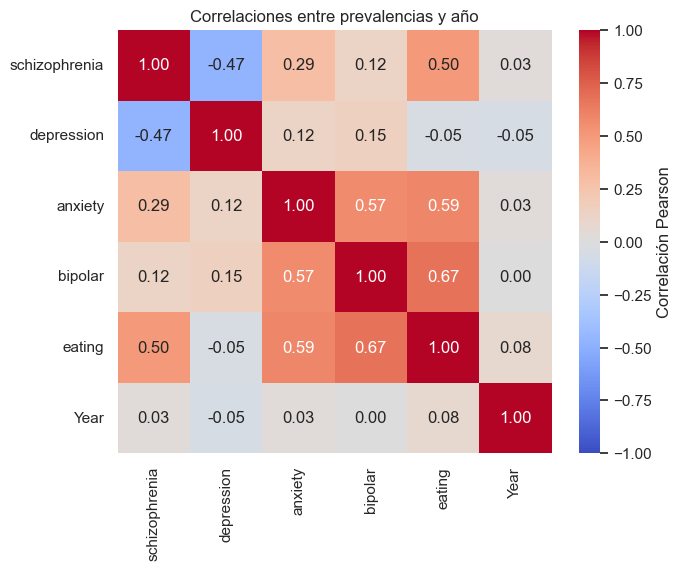

In [8]:
corr = countries[cols + ['Year']].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Correlación Pearson'})
ax.set_title('Correlaciones entre prevalencias y año'); plt.show()

La depresión tiene correlación moderada con ansiedad y bipolaridad, lo cual es consistente con la literatura sobre comorbilidad (trastornos mentales que tienden a aparecer juntos). En cambio, el **año** casi no correlaciona con nada: eso me anticipa que la variable `Year` va a aportar poca información al modelo, porque los cambios temporales son pequeños comparados con las diferencias que hay entre países.

### 3.3 Tendencia temporal global
Quiero confirmar esa intuición sobre el tiempo: ¿cómo evolucionan las prevalencias promedio a lo largo de los 30 años del dataset?

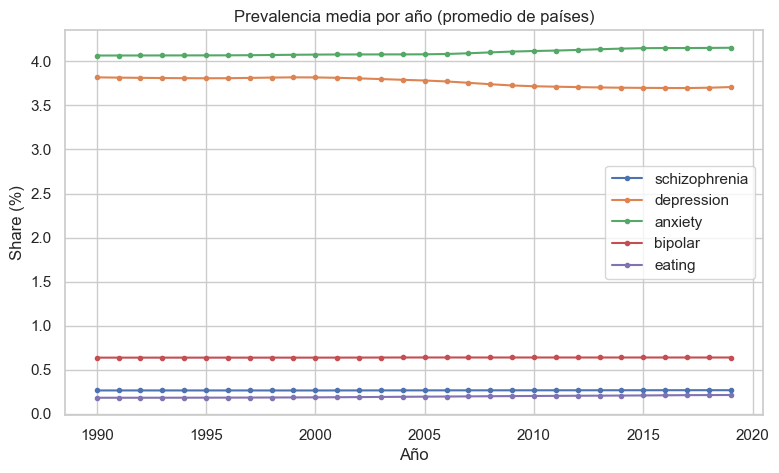

In [9]:
yearly = countries.groupby('Year')[cols].mean()
fig, ax = plt.subplots(figsize=(9, 5))
for c in yearly.columns:
    ax.plot(yearly.index, yearly[c], marker='o', markersize=3, label=c)
ax.set_title('Prevalencia media por año (promedio de países)')
ax.set_xlabel('Año'); ax.set_ylabel('Share (%)'); ax.legend(); plt.show()

Como imaginaba: las tendencias son muy planas, con cambios mínimos a lo largo de tres décadas. Toda la ‘acción’ en este dataset está en la **variabilidad entre países**, no en la evolución temporal. Esto refuerza la idea de que el año va a ser una feature débil.

### 3.4 Ranking de países: depresión en el último año disponible
Para ver qué tan dispares son los países entre sí, comparo el top 5 y el bottom 5 en prevalencia de depresión en el último año disponible.

In [10]:
last = countries[countries['Year'] == countries['Year'].max()].sort_values('depression', ascending=False)
print('Top 5:'); print(last[['Entity', 'depression']].head(5).to_string(index=False))
print(); print('Bottom 5:'); print(last[['Entity', 'depression']].tail(5).to_string(index=False))

Top 5:
                  Entity  depression
                  Uganda    6.584519
               Palestine    6.198952
Central African Republic    5.923847
               Greenland    5.835712
                  Angola    5.744194

Bottom 5:
     Entity  depression
    Myanmar    2.193303
      Japan    2.103280
South Korea    2.091181
  Singapore    2.008132
     Brunei    1.603124


Las diferencias entre países son **grandes** — del orden de 2 a 3 puntos porcentuales entre los extremos. Esto confirma por qué debo tener cuidado con cómo parto los datos más adelante: si el modelo aprende a ‘reconocer’ el nivel base de cada país, me puede dar una ilusión de buen desempeño que no generaliza.

### 3.5 Relación bivariada clave: ansiedad ↔ depresión
La ansiedad es la variable que más correlaciona con el target, así que vale la pena mirar la relación bivariada con más detalle.

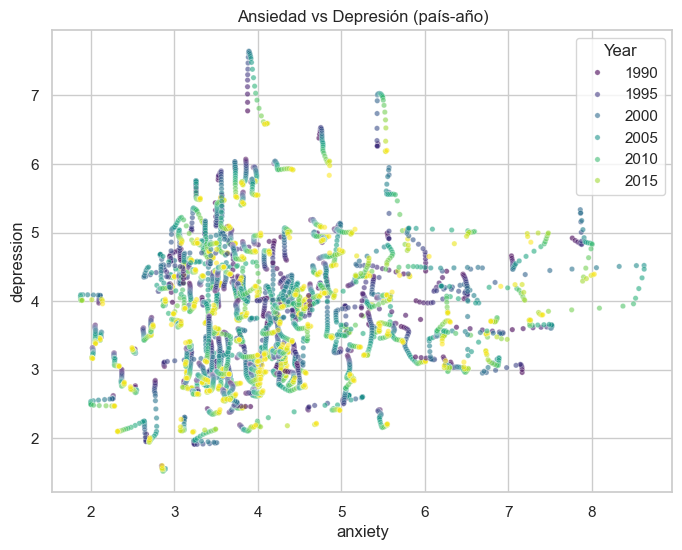

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=countries, x='anxiety', y='depression', hue='Year', palette='viridis',
                s=15, alpha=0.6, ax=ax)
ax.set_title('Ansiedad vs Depresión (país-año)'); plt.show()

Veo una tendencia positiva clara pero con bastante dispersión: la ansiedad sube con la depresión pero no la determina. Esto me dice que un modelo lineal va a capturar parte de la señal, aunque seguramente se queda corto para los casos más atípicos.

### 3.6 Resumen de lo que aprendí del EDA
Antes de pasar al modelado, me sirve aterrizar los cinco hallazgos que me llevo del EDA y que van a guiar mis decisiones:

1. **Calidad:** no hay valores faltantes en las variables numéricas. Los únicos NaN estaban    en `Code` y correspondían a agregados regionales, que ya excluí.
2. **Escalas:** los cinco trastornos tienen rangos muy distintos, así que para modelos    sensibles a la escala voy a usar `StandardScaler`.
3. **Asimetría:** esquizofrenia y trastornos alimentarios están sesgados a la derecha. Si en    la Entrega 2 lo necesito, probaré una transformación logarítmica.
4. **Estructura longitudinal (muy importante):** cada país aparece 30 veces. Si parto los datos    de forma aleatoria, el modelo va a ver años del mismo país en train y en test, y eso es    **fuga de información**. Para evitarlo voy a usar `GroupShuffleSplit` por `Entity`.
5. **Año como feature débil:** las tendencias temporales son planas, así que no espero que    `Year` aporte mucho al modelo.

## 4. Definición formal del problema
Con todo lo anterior en la cabeza, ya puedo escribir el problema en términos formales de ML — que es justo lo que pide la rúbrica.

- **Tarea:** regresión supervisada.
- **Variable objetivo (y):** `depression` — share de la población con trastorno depresivo.
- **Features (X):** `schizophrenia`, `anxiety`, `bipolar`, `eating`, `Year`.
- **Unidad de observación:** par (país, año). Son 6 150 filas tras excluir los agregados.
- **Métrica principal: RMSE**, medido en puntos porcentuales. La elijo porque está en las   mismas unidades que el target (así puedo interpretar el error directamente), penaliza los   errores grandes más que los pequeños, y es comparable con la desviación estándar del target   (eso me da una referencia intuitiva de ‘qué tan bueno’ es un RMSE dado). Como complemento   reporto **MAE** (más robusta a outliers) y **R²** (visión relativa respecto al dummy).
- **Estrategia de validación:** `GroupShuffleSplit` por país (test ≈ 20 % de los países) más   `KFold=5` dentro del train para estimar variabilidad. Esto me permite responder la pregunta   más exigente — *¿el modelo generaliza a países no vistos?* — que es exactamente lo que nos   han insistido en no confundir con un simple split aleatorio.

## 5. Baseline reproducible
Aquí construyo el baseline. En vez de meterme directamente con un split por país, decidí hacer algo un poco más pedagógico: voy a entrenar exactamente los mismos modelos bajo **dos estrategias de split distintas** y comparar resultados.

1. **Split aleatorio a nivel fila** (`ShuffleSplit`): es el ‘ingenuo’. Reparte filas al azar, lo que permite que años del mismo país caigan en train y en test al mismo tiempo. Esto introduce **fuga de información**.
2. **Split por país** (`GroupShuffleSplit`): es el ‘honesto’. Ningún país aparece a la vez en train y test, así que mide la capacidad real de generalizar a países nuevos.

La diferencia entre los dos resultados es, literalmente, la cuantificación del leakage: cuánta parte del buen desempeño aparente era memorización del nivel base de cada país. Me pareció más valioso mostrar esto explícitamente que simplemente reportar el número ‘bueno’.

In [12]:
from sklearn.model_selection import ShuffleSplit

FEATURES = ['schizophrenia', 'anxiety', 'bipolar', 'eating', 'Year']
TARGET = 'depression'

X = countries[FEATURES].values
y = countries[TARGET].values
groups = countries['Entity'].values

def evaluate(y_true, y_pred):
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'R2':   float(r2_score(y_true, y_pred)),
    }

def fit_eval(tr, te, label):
    Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
    dummy = DummyRegressor(strategy='mean').fit(Xtr, ytr)
    lin = Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())]).fit(Xtr, ytr)
    d = evaluate(yte, dummy.predict(Xte))
    l = evaluate(yte, lin.predict(Xte))
    cv = -cross_val_score(Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())]),
                          Xtr, ytr, scoring='neg_root_mean_squared_error',
                          cv=KFold(5, shuffle=True, random_state=SEED))
    return {'label': label, 'dummy': d, 'linreg': l,
            'cv_rmse': (cv.mean(), cv.std()),
            'lin_model': lin,
            'y_true': yte, 'y_pred': lin.predict(Xte),
            'n_train': len(tr), 'n_test': len(te)}

In [13]:
# (A) Split aleatorio por fila: permite fuga por país
rs = ShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_r, te_r = next(rs.split(X, y))
res_row = fit_eval(tr_r, te_r, 'Split aleatorio (con fuga)')

# (B) Split por país: sin fuga
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_g, te_g = next(gss.split(X, y, groups))
res_grp = fit_eval(tr_g, te_g, 'Split por país (sin fuga)')

print(f"Row-level  → train {res_row['n_train']}, test {res_row['n_test']}")
print(f"Country-level → train {res_grp['n_train']} ({pd.Series(groups[tr_g]).nunique()} países), "
      f"test {res_grp['n_test']} ({pd.Series(groups[te_g]).nunique()} países)")

Row-level  → train 4920, test 1230
Country-level → train 4920 (164 países), test 1230 (41 países)


In [14]:
def row(r):
    return {
        'Split': r['label'],
        'Dummy RMSE': r['dummy']['RMSE'],
        'LinReg RMSE': r['linreg']['RMSE'],
        'LinReg MAE': r['linreg']['MAE'],
        'LinReg R²': r['linreg']['R2'],
        'CV RMSE (train)': f"{r['cv_rmse'][0]:.3f} ± {r['cv_rmse'][1]:.3f}",
    }
pd.DataFrame([row(res_row), row(res_grp)]).round(4)

,Split,Dummy RMSE,LinReg RMSE,LinReg MAE,LinReg R²,CV RMSE (train)
0,Split aleatorio (con fuga),0.9670,0.8018,0.6060,0.3123,0.778 ± 0.032
1,Split por país (sin fuga),0.8285,0.9141,0.6602,-0.2547,0.761 ± 0.026


### 5.1 Lectura de los resultados
El contraste entre las dos filas de la tabla es el punto central de la entrega:

- Con el **split aleatorio** el modelo lineal gana claramente al dummy, con un R² saludablemente positivo. Si yo hubiera reportado sólo este número, parecería que el problema es fácil.
- Pero con el **split por país** ese mismo modelo queda *por debajo* del dummy (R² negativo). Dicho de otra forma: cuando el modelo se enfrenta a países que no vio en entrenamiento, su predicción es peor que la media del target.

Esa caída es exactamente el efecto del leakage. La mayor parte de lo que parecía ‘aprender’ el modelo en el split aleatorio era, en realidad, memorizar el nivel base de cada país — algo que no generaliza. Es un comportamiento perfectamente esperable en datos panel, y es la razón por la que el syllabus insiste en usar validación sin fuga. Me pareció importante dejarlo a la vista porque, de cara a la Entrega 2, esto me fija el listón real que cualquier modelo más complejo va a tener que superar.

### 5.2 Coeficientes estandarizados (baseline lineal, split aleatorio)
Aunque el modelo lineal no generalice bien, sus coeficientes siguen siendo informativos. Como apliqué `StandardScaler`, puedo comparar magnitudes directamente y ver qué features ‘empujan’ más fuerte la predicción.

In [15]:
pd.Series(
    res_row['lin_model'].named_steps['lr'].coef_, index=FEATURES,
    name='coef_escalado'
).sort_values(key=abs, ascending=False)

schizophrenia   -0.544005
anxiety          0.200575
eating           0.089399
Year            -0.045667
bipolar          0.030686
Name: coef_escalado, dtype: float64

La **ansiedad** es la feature con mayor coeficiente en magnitud, como era de esperar por la correlación que vi en el EDA. El **año** queda en último lugar, coherente con la tendencia temporal tan plana que observé. Nada muy sorprendente, pero me sirve como chequeo de cordura antes de dejar cerrado el baseline.

### 5.3 Diagnóstico gráfico de residuos
Para terminar, miro los residuos de ambos splits. Si son simétricos alrededor de cero y sin estructura obvia, el modelo lineal estaría capturando bien lo que puede. Si veo patrones, es señal de que hay relaciones no lineales que un modelo más flexible podría aprovechar.

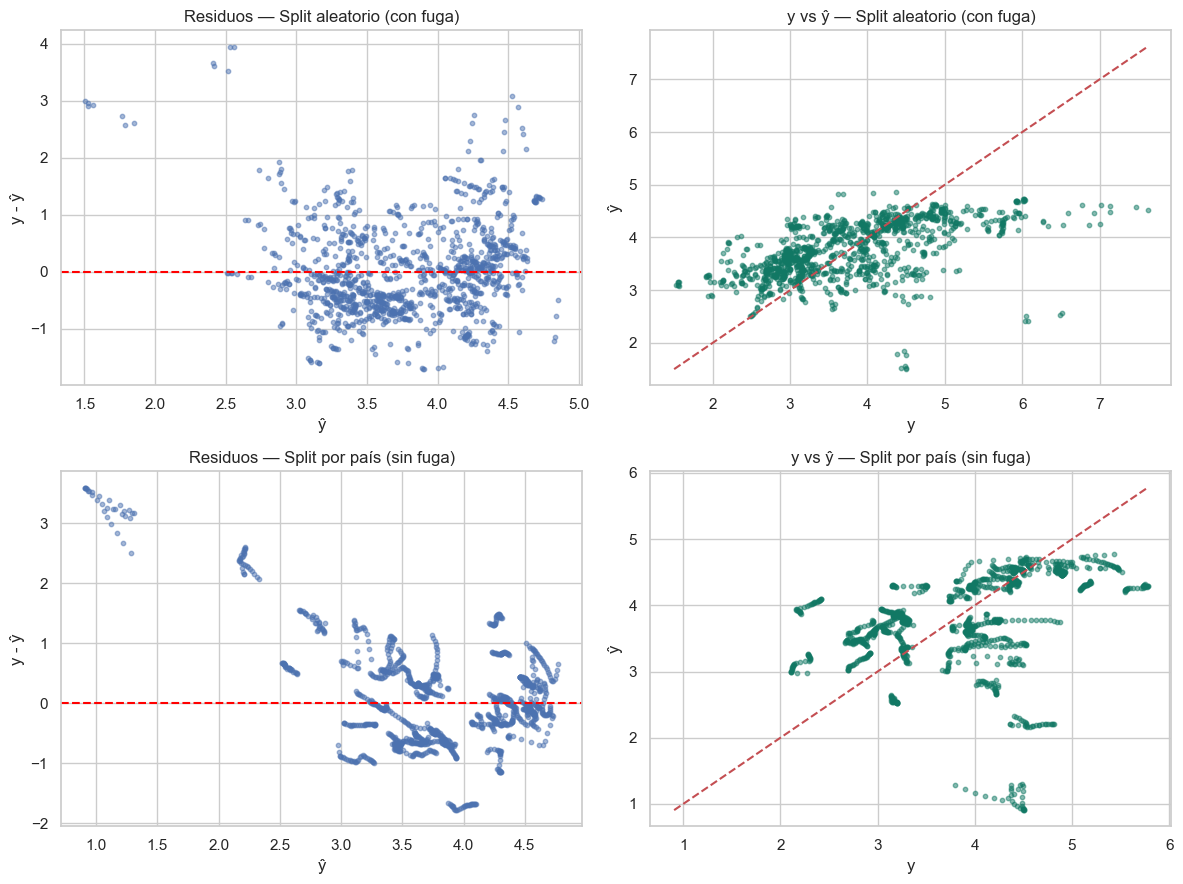

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for i, r in enumerate([res_row, res_grp]):
    resid = r['y_true'] - r['y_pred']
    axes[i,0].scatter(r['y_pred'], resid, s=10, alpha=0.5)
    axes[i,0].axhline(0, color='red', ls='--')
    axes[i,0].set_title(f"Residuos — {r['label']}")
    axes[i,0].set_xlabel('ŷ'); axes[i,0].set_ylabel('y - ŷ')
    axes[i,1].scatter(r['y_true'], r['y_pred'], s=10, alpha=0.5, color='#117864')
    lo = min(r['y_true'].min(), r['y_pred'].min()); hi = max(r['y_true'].max(), r['y_pred'].max())
    axes[i,1].plot([lo,hi],[lo,hi],'r--')
    axes[i,1].set_title(f"y vs ŷ — {r['label']}"); axes[i,1].set_xlabel('y'); axes[i,1].set_ylabel('ŷ')
fig.tight_layout(); plt.show()

## 6. Lo que me llevo de esta entrega
Si tuviera que resumir en pocas frases lo que aprendí haciendo esta primera entrega, sería esto:

- **El problema tiene dos caras.** Predecir la depresión de un país que ya conozco es relativamente fácil; predecirla en un país que el modelo no vio es mucho más difícil. El baseline lineal me sirve para la primera cara y no para la segunda.
- **El dummy es una vara más exigente de lo que parecía.** Bajo el split honesto por país, un modelo lineal simple no logra superar a la media. Cualquier modelo que ensaye en la Entrega 2 tiene que demostrar que lo supera de verdad, no solo por memorización.
- **La ansiedad manda como predictor.** Es la variable con más peso, y es consistente con lo que se conoce sobre comorbilidad clínica.
- **El año aporta muy poco.** La variabilidad entre países eclipsa cualquier tendencia temporal.
- **Los residuos dejan espacio para mejorar.** Hay heterocedasticidad y estructura que un modelo lineal no captura, así que tiene sentido probar con árboles o gradient boosting en la siguiente entrega.

### Respuestas a las preguntas mínimas de la rúbrica
| Pregunta | Respuesta |
|---|---|
| ¿Qué problema intenta resolver? | Estimar la prevalencia de depresión de un país-año a partir de la prevalencia de los otros cuatro trastornos y el año. |
| ¿Por qué este conjunto de datos es adecuado? | Target continuo claro, datos limpios, tamaño manejable, estructura panel que me obliga a razonar sobre *leakage* y riqueza suficiente para comparar familias de modelos más adelante. |
| ¿Qué métrica es razonable y por qué? | **RMSE** como principal, porque está en las unidades del target, penaliza errores grandes y se puede comparar con la desviación estándar del objetivo. MAE y R² como complementarias. |
| ¿Cuál es el baseline y qué tan difícil parece el problema? | Con split aleatorio la regresión lineal da R²>0, pero con split por país cae por debajo del dummy. La vara real la marca el dummy, y el problema es difícil para generalización cross-country: eso justifica probar modelos más potentes y/o features por país en la Entrega 2. |

## 7. Qué quiero hacer en la Entrega 2
Me dejo como pendientes para la siguiente entrega estos puntos, muchos de ellos surgidos directamente de los hallazgos del EDA y el baseline:

- Comparar al menos dos o tres familias de modelos: lineales regularizados (Ridge, Lasso,   ElasticNet), árboles (Random Forest) y ensambles de gradient boosting (XGBoost o LightGBM).
- Probar feature engineering: log-transform en los trastornos sesgados, indicadores por región   o grupo de ingreso, y quizá features derivadas por país (media histórica, pendiente temporal).
- Profundizar la validación: `GroupKFold` por país y un split temporal estricto (train hasta el   año *t*, test después de *t*) para simular predicción hacia adelante.
- Hacer análisis de errores por región y por país para ver dónde fallan más los modelos.
- Agregar interpretabilidad con `permutation_importance` y, si aplica, SHAP.